# Waddington-OT on consecutive single-cell snapshots

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2026 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:kantorovich-waddington-ot` from the public iPSC reprogramming data and transport map of Schiebinger et al. It follows the original paper's visualization principle: the force-layout embedding (FLE) is a common display landscape, while transported ancestor and descendant **probabilities** are encoded by color intensity. In particular, no straight-line interpolation in the FLE is interpreted as a biological trajectory.

In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('IPython', 'ipython'),
)
_OT4ML_REQUIRED_FILES = (
    'notebooks-figures/assets/waddington_ot_day10_day10_5.npz',
)
ROOT = _OT4ML_STYLE.configure_notebook(
    packages=_OT4ML_PACKAGES,
    required_files=_OT4ML_REQUIRED_FILES,
)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT


In [2]:
from pathlib import Path
import shutil

from IPython.display import Image as DisplayImage
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import numpy as np

from figure_style import (
    BLUE,
    LIGHT_GRAY,
    RED,
    VIOLET,
    figure_dir,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "kantorovich-waddington-ot"
OUT = figure_dir(NAME)
ASSET = FIGROOT / "assets" / "waddington_ot_day10_day10_5.npz"
THUMBNAIL = FIGROOT / "thumbnails" / f"{NAME}.png"
ARXIV_OUTPUT = ROOT / "arxiv" / "figures" / f"{NAME}--waddington-ot.pdf"

## Released coupling and official display coordinates

Let $P\in\mathbb R_+^{n_0\times n_1}$ be the released growth-aware, entropic Waddington-OT plan from day $10$ to day $10.5$. Its cost was computed in the authors' local 30-dimensional PCA geometry. The two-dimensional FLE was instead obtained from a nearest-neighbor graph over the complete reprogramming time course and is used only for visualization.

The reduced asset stores the two endpoint clouds, a random background sample from the complete FLE, and probability vectors obtained from $P$. It contains neither expression vectors nor cell identifiers.

In [3]:
def load_reduced_waddington_data(path: Path) -> dict[str, np.ndarray]:
    """Load and validate the compact paper-style Waddington-OT asset.

    Args:
        path: Repository-local NPZ file prepared from the official tutorial data.

    Returns:
        Dictionary containing FLE coordinates, conditioning sets, transported
        probabilities, and collection times.

    Raises:
        FileNotFoundError: If the reduced asset is unavailable.
        ValueError: If an array has an invalid shape or normalization.
    """
    if not path.exists():
        raise FileNotFoundError(f"Missing Waddington-OT asset: {path}")
    with np.load(path) as archive:
        data = {name: archive[name] for name in archive.files}

    for name in ("background", "source", "target"):
        if data[name].ndim != 2 or data[name].shape[1] != 2:
            raise ValueError(f"{name} must contain planar FLE coordinates")
    for name in ("source_seed", "target_a", "target_b"):
        if data[name].ndim != 1 or not np.issubdtype(data[name].dtype, np.integer):
            raise ValueError(f"{name} must be a one-dimensional integer array")
    expected_lengths = {
        "descendant_mass": len(data["target"]),
        "ancestor_a_mass": len(data["source"]),
        "ancestor_b_mass": len(data["source"]),
    }
    for name, expected_length in expected_lengths.items():
        values = data[name]
        if values.shape != (expected_length,) or np.any(values < 0.0):
            raise ValueError(f"{name} has invalid shape or negative entries")
        if not np.isclose(values.sum(), 1.0, atol=1e-6):
            raise ValueError(f"{name} must have unit total mass")
    return data


data = load_reduced_waddington_data(ASSET)
source = data["source"]
target = data["target"]
source_day = float(data["source_day"])
target_day = float(data["target_day"])
print(
    f"{len(source):,} day-{source_day:g} cells and "
    f"{len(target):,} day-{target_day:g} cells in the official FLE."
)

2,051 day-10 cells and 1,941 day-10.5 cells in the official FLE.


## Push-forward, pull-back, and shared ancestry

Let $\mathrm a_C$ be uniform on a compact source-cell set $C$, and let $\mathrm b_A,\mathrm b_B$ be uniform on two separated target regions. Using column vectors, the displayed descendant and ancestor laws are

$$
\mathrm b_C^{\mathrm{desc}}
=
\frac{P^\top \mathrm a_C}{\langle P^\top \mathrm a_C,\mathbf 1\rangle},
\qquad
\mathrm a_R^{\mathrm{anc}}
=
\frac{P\mathrm b_R}{\langle P\mathrm b_R,\mathbf 1\rangle},
\quad R\in\{A,B\}.
$$

Thus $\mathrm b_C^{\mathrm{desc}}$ pushes the source selection forward, whereas $\mathrm a_A^{\mathrm{anc}}$ and $\mathrm a_B^{\mathrm{anc}}$ pull the two target selections backward. The regions $A$ and $B$ are chosen to be separated in the display while retaining appreciable pulled-back overlap; $C$ is a compact subset of this common-ancestor region. Their shared ancestry is rendered through the componentwise decomposition

$$
\mathrm a_A^{\mathrm{anc}}
=(\mathrm a_A^{\mathrm{anc}}-\mathrm a_B^{\mathrm{anc}})_+
 + \mathrm a_\cap^{\mathrm{anc}},
\qquad
\mathrm a_B^{\mathrm{anc}}
=(\mathrm a_B^{\mathrm{anc}}-\mathrm a_A^{\mathrm{anc}})_+
 + \mathrm a_\cap^{\mathrm{anc}},
$$

where

$$
\mathrm a_\cap^{\mathrm{anc}}
=\min\{\mathrm a_A^{\mathrm{anc}},\mathrm a_B^{\mathrm{anc}}\}.
$$

Red and blue show region-specific ancestor mass, while violet shows $\mathrm a_\cap^{\mathrm{anc}}$. This follows the probability-on-FLE logic used in the original Waddington-OT paper: the transport plan propagates probabilities, while the force-layout embedding supplies only display coordinates.

In [4]:
def common_limits(
    source_points: np.ndarray,
    target_points: np.ndarray,
    *,
    quantile: float = 0.005,
    padding: float = 0.045,
) -> tuple[tuple[float, float], tuple[float, float]]:
    """Compute robust common limits for all FLE panels.

    Args:
        source_points: Source coordinates of shape ``(n, 2)``.
        target_points: Target coordinates of shape ``(m, 2)``.
        quantile: Tail fraction removed at each side.
        padding: Fractional padding relative to the retained coordinate span.

    Returns:
        Horizontal and vertical plotting limits.
    """
    points = np.vstack([source_points, target_points])
    lower = np.quantile(points, quantile, axis=0)
    upper = np.quantile(points, 1.0 - quantile, axis=0)
    margin = padding * np.maximum(upper - lower, 1e-12)
    lower -= margin
    upper += margin
    return (lower[0], upper[0]), (lower[1], upper[1])


def robust_strength(mass: np.ndarray, *, quantile: float = 0.985) -> np.ndarray:
    """Map probability mass to a robust display intensity in ``[0, 1]``.

    Args:
        mass: Nonnegative probability vector.
        quantile: Positive-mass quantile mapped to full intensity.

    Returns:
        Square-root-compressed display strengths.
    """
    mass = np.maximum(np.asarray(mass, dtype=float), 0.0)
    positive = mass[mass > 0.0]
    if len(positive) == 0:
        return np.zeros_like(mass)
    scale = float(np.quantile(positive, quantile))
    return np.sqrt(np.clip(mass / max(scale, np.finfo(float).tiny), 0.0, 1.0))


def draw_background(
    ax: plt.Axes,
    background: np.ndarray,
    x_limits: tuple[float, float],
    y_limits: tuple[float, float],
) -> None:
    """Draw the common gray FLE landscape inside the local viewport."""
    visible = (
        (background[:, 0] >= x_limits[0])
        & (background[:, 0] <= x_limits[1])
        & (background[:, 1] >= y_limits[0])
        & (background[:, 1] <= y_limits[1])
    )
    ax.scatter(
        background[visible, 0],
        background[visible, 1],
        s=0.42,
        color=LIGHT_GRAY,
        alpha=0.38,
        linewidths=0,
        zorder=0,
    )


def draw_weighted_cells(
    ax: plt.Axes,
    points: np.ndarray,
    mass: np.ndarray,
    color: str,
    *,
    threshold: float = 0.035,
    zorder: int = 2,
) -> None:
    """Render a probability distribution through marker size and opacity.

    Args:
        ax: Matplotlib axes receiving the cells.
        points: Cell coordinates of shape ``(n, 2)``.
        mass: Nonnegative probability vector of length ``n``.
        color: Base marker color.
        threshold: Minimum robust strength displayed.
        zorder: Matplotlib drawing order.
    """
    strength = robust_strength(mass)
    visible = strength >= threshold
    rgba = np.tile(to_rgba(color), (int(visible.sum()), 1))
    rgba[:, 3] = 0.12 + 0.80 * strength[visible]
    ax.scatter(
        points[visible, 0],
        points[visible, 1],
        s=1.4 + 8.0 * strength[visible],
        color=rgba,
        linewidths=0,
        zorder=zorder,
    )


def draw_conditioning_set(
    ax: plt.Axes,
    points: np.ndarray,
    indices: np.ndarray,
    color: str,
) -> None:
    """Highlight cells defining a source or target conditioning set."""
    ax.scatter(
        points[indices, 0],
        points[indices, 1],
        s=7.2,
        color=color,
        edgecolors="#202020",
        linewidths=0.26,
        zorder=5,
    )


def draw_set_label(
    ax: plt.Axes,
    points: np.ndarray,
    indices: np.ndarray,
    label: str,
    *,
    offset: tuple[float, float] = (6.0, 5.0),
) -> None:
    """Label a conditioning set at its robust coordinate center.

    Args:
        ax: Matplotlib axes receiving the label.
        points: Cell coordinates of shape ``(n, 2)``.
        indices: Integer indices of the conditioning cells.
        label: Short mathematical set label.
        offset: Label displacement in typographic points.
    """
    center = np.median(points[indices], axis=0)
    ax.annotate(
        rf"${label}$",
        xy=center,
        xytext=offset,
        textcoords="offset points",
        fontsize=6.6,
        fontweight="semibold",
        color="#202020",
        ha="center",
        va="center",
        bbox={
            "boxstyle": "round,pad=0.12",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.88,
        },
        zorder=7,
    )

## Paper-style four-panel rendering

Every panel uses the same viewport and gray background. Black rims and the labels $A$, $B$, and $C$ identify the conditioning cells. The first panel shows the two observed snapshots; the next panels show probability propagation rather than interpolated point locations.

In [5]:
def render_figure(dataset: dict[str, np.ndarray]) -> plt.Figure:
    """Render observed snapshots and paper-style transport summaries.

    Args:
        dataset: Validated reduced Waddington-OT asset.

    Returns:
        Complete four-panel Matplotlib figure.
    """
    figure, axes = plt.subplots(1, 4, figsize=(7.50, 2.02))
    x_limits, y_limits = common_limits(source, target)
    for axis in axes:
        draw_background(axis, dataset["background"], x_limits, y_limits)
        axis.set_xlim(*x_limits)
        axis.set_ylim(*y_limits)
        axis.set_aspect("equal", adjustable="box")
        remove_axes(axis)

    # Observed endpoint populations.
    axes[0].scatter(source[:, 0], source[:, 1], s=2.0, color=RED, alpha=0.50, linewidths=0)
    axes[0].scatter(target[:, 0], target[:, 1], s=2.0, color=BLUE, alpha=0.48, linewidths=0)
    axes[0].text(0.03, 0.03, f"day {source_day:g}", color=RED, fontsize=7.0, transform=axes[0].transAxes)
    axes[0].text(0.97, 0.03, f"day {target_day:g}", color=BLUE, fontsize=7.0, ha="right", transform=axes[0].transAxes)

    # Push a source cell set forward to its descendants.
    draw_weighted_cells(axes[1], target, dataset["descendant_mass"], BLUE)
    draw_conditioning_set(axes[1], source, dataset["source_seed"], RED)
    draw_set_label(axes[1], source, dataset["source_seed"], "C", offset=(-7.0, -7.0))

    # Pull target region A back to its ancestors.
    draw_weighted_cells(axes[2], source, dataset["ancestor_a_mass"], RED)
    draw_conditioning_set(axes[2], target, dataset["target_a"], BLUE)
    draw_set_label(axes[2], target, dataset["target_a"], "A")

    # Decompose the two pulled-back laws into exclusive and shared mass.
    ancestor_a = dataset["ancestor_a_mass"]
    ancestor_b = dataset["ancestor_b_mass"]
    shared = np.minimum(ancestor_a, ancestor_b)
    draw_weighted_cells(axes[3], source, np.maximum(ancestor_a - ancestor_b, 0.0), RED)
    draw_weighted_cells(axes[3], source, np.maximum(ancestor_b - ancestor_a, 0.0), BLUE)
    draw_weighted_cells(axes[3], source, shared, VIOLET, threshold=0.02, zorder=4)
    draw_conditioning_set(axes[3], target, dataset["target_a"], RED)
    draw_conditioning_set(axes[3], target, dataset["target_b"], BLUE)
    draw_set_label(axes[3], target, dataset["target_a"], "A")
    draw_set_label(axes[3], target, dataset["target_b"], "B")

    titles = (
        "observed snapshots",
        r"descendants of $C$",
        r"ancestors of $A$",
        r"shared ancestry of $A,B$",
    )
    for axis, title in zip(axes, titles):
        axis.set_title(title, fontsize=8.0, pad=2.0)
    figure.subplots_adjust(left=0.004, right=0.996, bottom=0.015, top=0.89, wspace=0.035)
    return figure


figure = render_figure(data)
output_path = OUT / "waddington-ot.pdf"
save_pdf(figure, output_path, pad_inches=0.015)
ARXIV_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(output_path, ARXIV_OUTPUT)
THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)
figure.savefig(
    THUMBNAIL,
    dpi=250,
    bbox_inches="tight",
    pad_inches=0.015,
    facecolor="white",
)
plt.close(figure)
print(f"Saved {output_path}")

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/kantorovich-waddington-ot/waddington-ot.pdf


## Figure preview

The vector PDF above is included in the manuscript. In the shared-ancestry panel, red and blue mark the exclusive parts $(\mathrm a_A^{\mathrm{anc}}-\mathrm a_B^{\mathrm{anc}})_+$ and $(\mathrm a_B^{\mathrm{anc}}-\mathrm a_A^{\mathrm{anc}})_+$, while violet marks their pointwise common part $\mathrm a_\cap^{\mathrm{anc}}$.

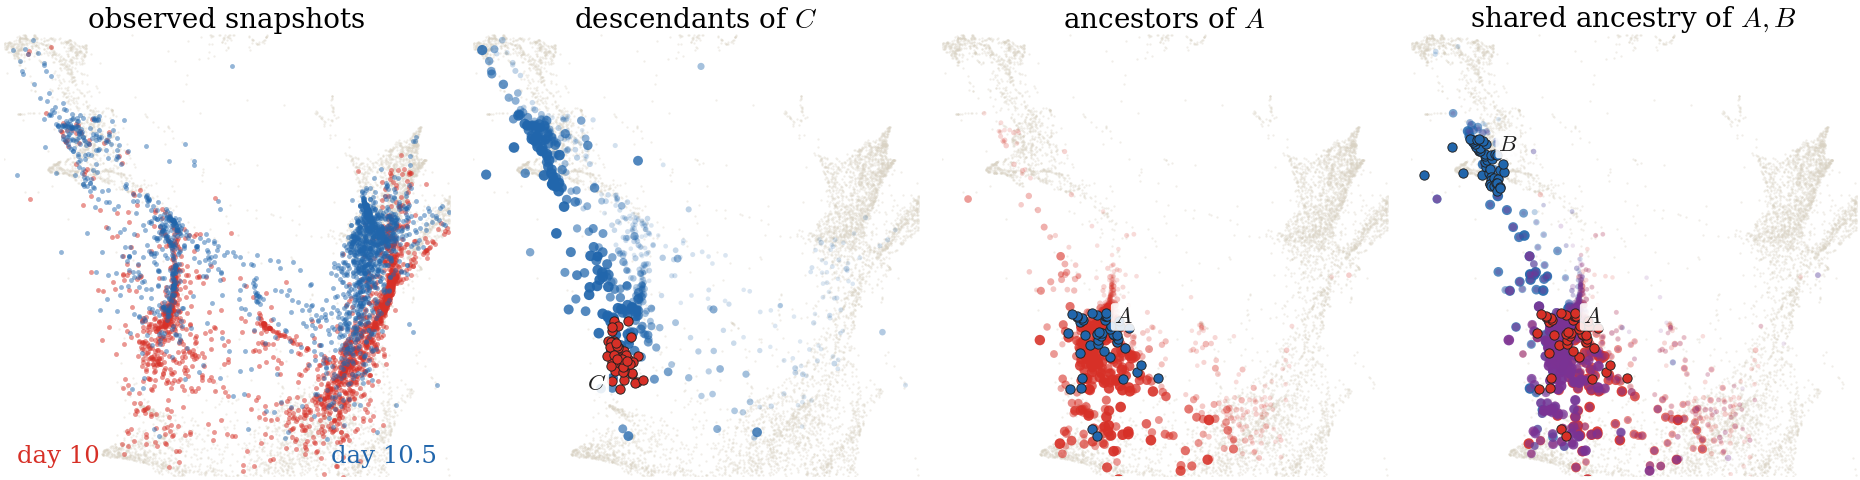

In [6]:
display(DisplayImage(filename=str(THUMBNAIL), width=1100))